In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
def load_sample(folder):
    if not os.path.exists(folder):
        print(f"❌ Folder not found: {folder}")
        return None
    
    files = os.listdir(folder)
    
    if len(files) == 0:
        print(f"❌ No files in: {folder}")
        return None
    
    file_path = os.path.join(folder, files[0])
    print("✅ Loading:", file_path)
    
    return np.load(file_path)

In [5]:
def show_map(data, title):
    if data is None:
        return
    
    print("Shape:", data.shape)

    # 🔥 Fix different shapes
    if len(data.shape) == 3:
        data = data[0]   # take first channel
    
    if len(data.shape) == 4:
        data = data[0][0]  # batch + channel

    plt.figure(figsize=(6,5))
    plt.imshow(data, cmap='hot')
    plt.colorbar()
    plt.title(title)
    plt.axis('off')
    plt.show()

✅ Loading: work_dir/congestion_gpdl/test_result\synthetic_congestion_path_0.npy
Shape: (1, 1, 256, 256)


d:\Coding\Main Projects\TimeSeriesFintech\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


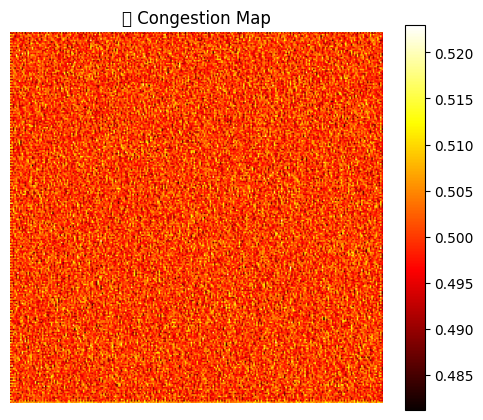

In [6]:
congestion = load_sample("work_dir/congestion_gpdl/test_result")
show_map(congestion, "🔥 Congestion Map")

✅ Loading: work_dir/drc/test_result\0.npy
Shape: (1, 1, 256, 256)


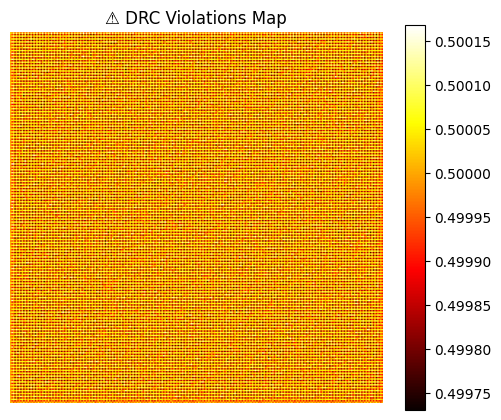

In [7]:
drc = load_sample("work_dir/drc/test_result")
show_map(drc, "⚠️ DRC Violations Map")

✅ Loading: work_dir/irdrop/test_result\0.npy
Shape: (1, 1, 256, 256)


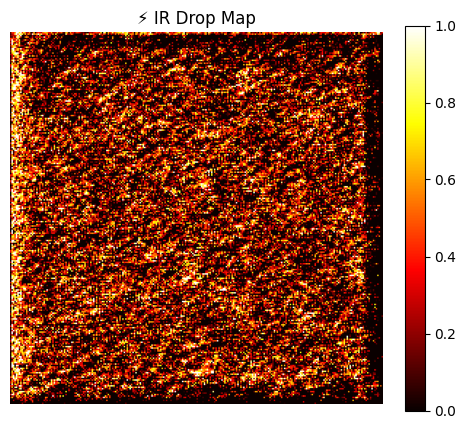

In [8]:
irdrop = load_sample("work_dir/irdrop/test_result")
show_map(irdrop, "⚡ IR Drop Map")

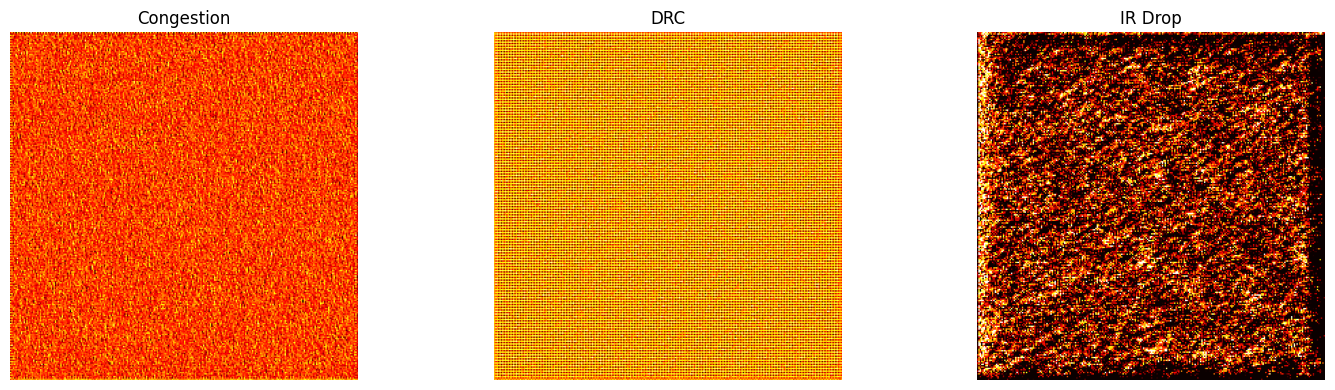

In [10]:
plt.figure(figsize=(15,4))

maps = [
    (congestion, "Congestion"),
    (drc, "DRC"),
    (irdrop, "IR Drop")
]

for i, (data, title) in enumerate(maps):
    if data is None:
        continue

    # 🔥 FIX SHAPE
    if len(data.shape) == 4:
        data = data[0][0]
    elif len(data.shape) == 3:
        data = data[0]

    plt.subplot(1,3,i+1)
    plt.imshow(data, cmap='hot')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

✅ Saved as congestion_map.png


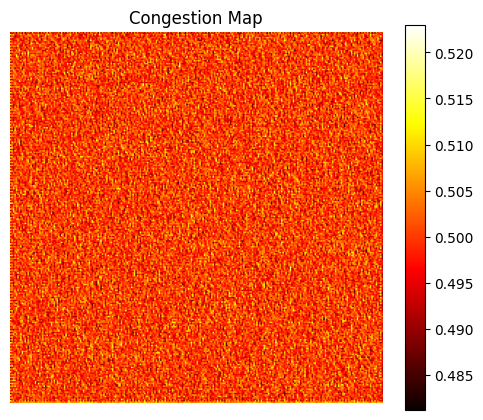

In [12]:
plt.figure(figsize=(6,5))

data = congestion[0][0]   # 🔥 FIX HERE

plt.imshow(data, cmap='hot')
plt.colorbar()
plt.title("Congestion Map")
plt.axis('off')

plt.savefig("congestion_map.png", bbox_inches='tight')
print("✅ Saved as congestion_map.png")